# KONFIGURASI DAN IMPORT LIBRARY

In [143]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# LOAD DATA

In [144]:
# read data csv
# drive
lokasidata = '/content/drive/My Drive/big_data/'
df = pd.read_csv(lokasidata + 'cropdata_updated.csv')

# local
# data_path = os.path.join('data', 'raw', 'cropdata_updated.csv')
# df = pd.read_csv(data_path)

df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [145]:
df.columns

Index(['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity',
       'result'],
      dtype='object')

In [146]:
# STUKTUR DATA AWAL
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


# EDA

In [147]:
# EDA
df.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [148]:
# STANDARISASI NAMA KOLOM
df.columns = df.columns.str.lower().str.replace(' ', '_')
df = df.rename(columns={'temp': 'temperature'})
print(df.columns.tolist())

['crop_id', 'soil_type', 'seedling_stage', 'moi', 'temperature', 'humidity', 'result']


In [149]:
# CLEANING STRING VALUE
text_columns = ['crop_id', 'soil_type', 'seedling_stage']
for col in text_columns:
    if col in df.columns:
        # Ubah jadi string, hapus spasi depan-belakang, dan standarisasi huruf besar di awal kata
        df[col] = df[col].astype(str).str.strip().str.title()
        # Perbaiki tipe data jadi 'category' untuk menghemat memori
        df[col] = df[col].astype('category')
df.head()

,crop_id,soil_type,seedling_stage,moi,temperature,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


# CHECK & CLEANING DATA

In [151]:
# CHECK MISSING VALUES
total = df.isna().sum()
percent = total/df.isna().count()*100
pd.DataFrame({'total':total,'percent':percent})

,total,percent
crop_id,0,0.0
soil_type,0,0.0
seedling_stage,0,0.0
moi,0,0.0
temperature,0,0.0
humidity,0,0.0
result,0,0.0


In [152]:
# CHECK DATA DUPLIKAT
total_duplicated_data = df.duplicated(subset=['crop_id','soil_type','seedling_stage','moi','temperature','humidity','result']).sum()
print("TOTAL DATA DUPLIKAT :", total_duplicated_data)

df[df.duplicated(subset=['crop_id','soil_type','seedling_stage','moi','temperature','humidity','result'])]

TOTAL DATA DUPLIKAT : 128


,crop_id,soil_type,seedling_stage,moi,temperature,humidity,result
8511,Potato,Clay Soil,Seedling Stage,1,18,86.0,0
8512,Potato,Clay Soil,Seedling Stage,2,17,87.0,0
8513,Potato,Clay Soil,Seedling Stage,3,16,88.0,0
8514,Potato,Clay Soil,Seedling Stage,4,15,89.0,0
8515,Potato,Clay Soil,Seedling Stage,5,14,90.0,0
...,...,...,...,...,...,...,...
12313,Carrot,Sandy Soil,Flowering,65,19,85.0,0
12314,Carrot,Sandy Soil,Flowering,66,18,86.0,0
12315,Carrot,Sandy Soil,Flowering,67,17,87.0,0
12316,Carrot,Sandy Soil,Flowering,68,16,88.0,0


In [153]:
# REMOVE DUPLICATES
baris_awal = len(df)
df = df.drop_duplicates()
baris_akhir = len(df)
print(f"\nDuplikat dihapus: {baris_awal - baris_akhir} baris")

print("Total Data Duplikat : ", df.duplicated().sum())


Duplikat dihapus: 128 baris
Total Data Duplikat :  0


In [154]:
# HANDLE MISSING VALUES
df = df.ffill().bfill()

# HANDLE OUTLIERS
numeric_columns = ['moi', 'temperature', 'humidity', 'result']
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=batas_bawah, upper=batas_atas)

df.head()

,crop_id,soil_type,seedling_stage,moi,temperature,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [155]:
# penambahan kolom time series (dummy data)
waktu_sekarang = datetime.now()
df['timestamp'] = [waktu_sekarang - timedelta(hours=len(df)-i) for i in range(len(df))]
print("Kolom 'timestamp' berhasil ditambahkan!")
cols = ['timestamp'] + [col for col in df.columns if col != 'timestamp']
df = df[cols]
df.head()

Kolom 'timestamp' berhasil ditambahkan!


,timestamp,crop_id,soil_type,seedling_stage,moi,temperature,humidity,result
0,2024-05-01 04:32:21.974394,Wheat,Black Soil,Germination,1,25,80.0,1
1,2024-05-01 05:32:21.974394,Wheat,Black Soil,Germination,2,26,77.0,1
2,2024-05-01 06:32:21.974394,Wheat,Black Soil,Germination,3,27,74.0,1
3,2024-05-01 07:32:21.974394,Wheat,Black Soil,Germination,4,28,71.0,1
4,2024-05-01 08:32:21.974394,Wheat,Black Soil,Germination,5,29,68.0,1


In [156]:
print("=== HASIL DATA QUALITY SCORE ===")

# Hitung base metric
total_records = len(df)
total_cells = df.size
total_missing = df.isnull().sum().sum()

accuracy = 1 - (total_missing / total_cells)

total_non_null = df.notnull().sum().sum()
completeness = total_non_null / total_cells

end_date = df['timestamp'].max()
thirty_days_ago = end_date - pd.Timedelta(days=30)
data_last_30_days = df[df['timestamp'] >= thirty_days_ago].shape[0]

timeliness = data_last_30_days / total_records

print(f"Accuracy     : {accuracy * 100:.2f}%")
print(f"Completeness : {completeness * 100:.2f}%")
print(f"Timeliness   : {timeliness * 100:.2f}% (Jumlah data 30 hari terakhir: {data_last_30_days} baris)")

=== HASIL DATA QUALITY SCORE ===
Accuracy     : 100.00%
Completeness : 100.00%
Timeliness   : 4.43% (Jumlah data 30 hari terakhir: 721 baris)


# ANALISIS DATA

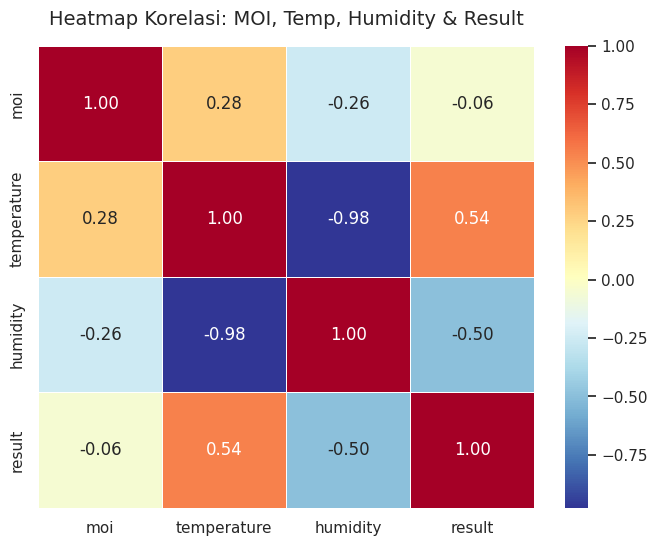

In [157]:
# ANALISIS
# CORRELATION HEATMAP
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
korelasi = df[numeric_columns].corr()

sns.heatmap(korelasi, annot=True, cmap='RdYlBu_r', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi: MOI, Temp, Humidity & Result', fontsize=14, pad=15)
plt.show()

--- GRAFIK TIME SERIES (RATA-RATA PER BULAN) ---


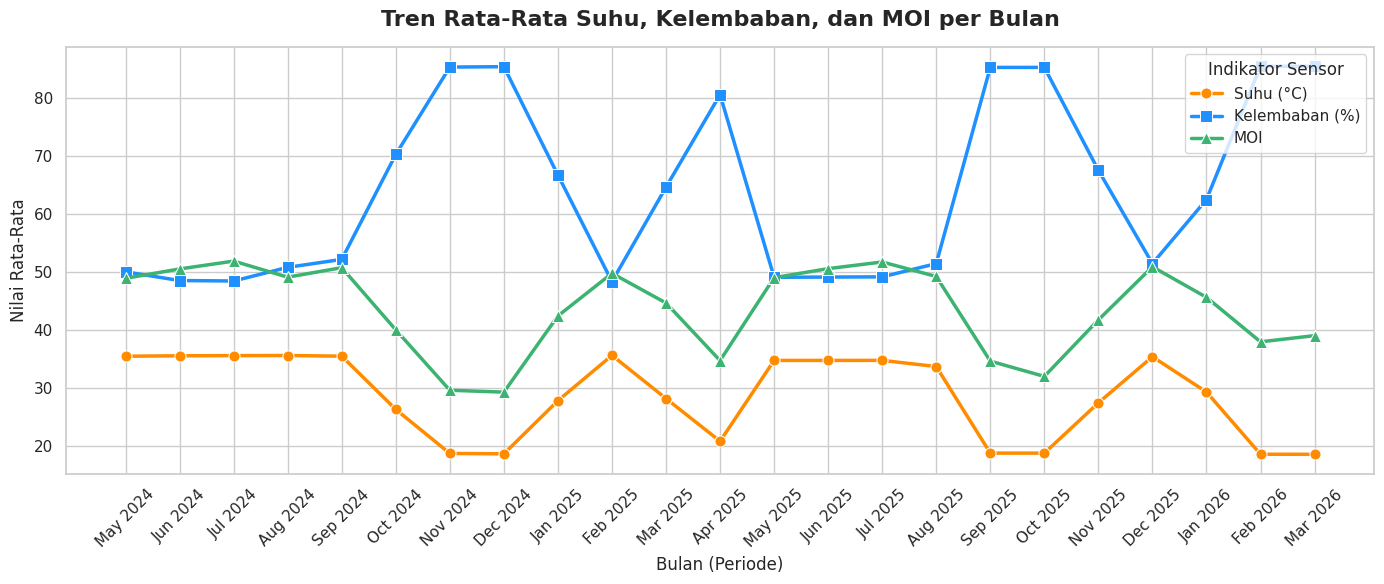

In [158]:
# TIME SERIES TREND
print("--- GRAFIK TIME SERIES (RATA-RATA PER BULAN) ---")

df_monthly = df.set_index('timestamp').resample('ME').mean(numeric_only=True).reset_index()

df_monthly['Bulan'] = df_monthly['timestamp'].dt.strftime('%b %Y')

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df_monthly, x='Bulan', y='temperature', label='Suhu (°C)', color='darkorange', marker='o', markersize=8, linewidth=2.5)
sns.lineplot(data=df_monthly, x='Bulan', y='humidity', label='Kelembaban (%)', color='dodgerblue', marker='s', markersize=8, linewidth=2.5)
sns.lineplot(data=df_monthly, x='Bulan', y='moi', label='MOI', color='mediumseagreen', marker='^', markersize=8, linewidth=2.5)

plt.title('Tren Rata-Rata Suhu, Kelembaban, dan MOI per Bulan', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Bulan (Periode)', fontsize=12)
plt.ylabel('Nilai Rata-Rata', fontsize=12)

plt.xticks(rotation=45)
plt.legend(title='Indikator Sensor', loc='upper right')
plt.tight_layout()
plt.show()

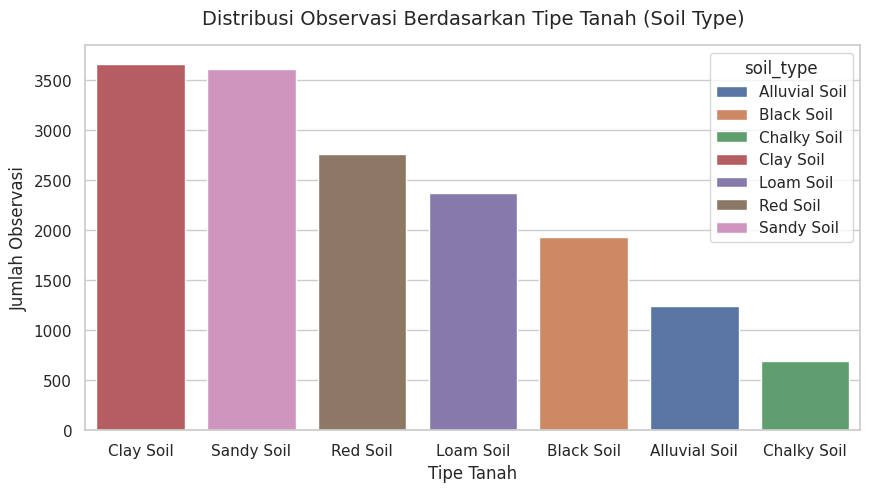

In [159]:
# BAR CHART DISTRIBUSI TIPE TANAH
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='soil_type', hue='soil_type', legend=True, order=df['soil_type'].value_counts().index)
plt.title('Distribusi Observasi Berdasarkan Tipe Tanah (Soil Type)', fontsize=14, pad=15)
plt.xlabel('Tipe Tanah', fontsize=12)
plt.ylabel('Jumlah Observasi', fontsize=12)
plt.show()

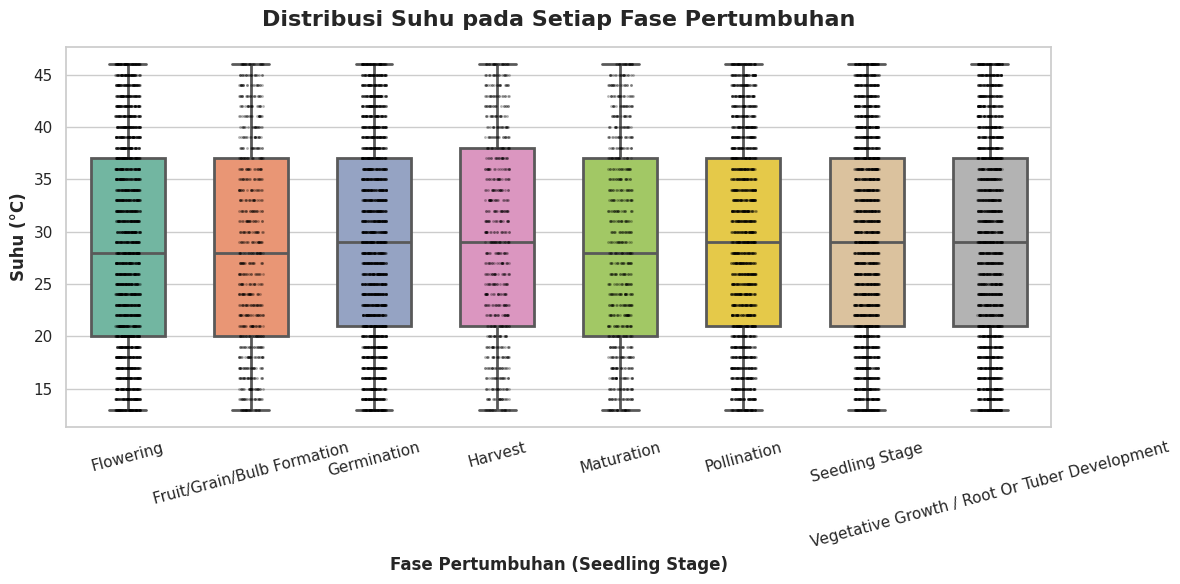

In [160]:
# BOXPLOT (Distribusi Suhu berdasarkan Fase Tumbuh)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='seedling_stage',
    y='temperature',
    hue='seedling_stage',
    palette='Set2',
    legend=False,
    linewidth=2,
    width=0.6
)

sns.stripplot(
    data=df,
    x='seedling_stage',
    y='temperature',
    color='black',
    alpha=0.3,
    jitter=True,
    size=2
)

plt.title('Distribusi Suhu pada Setiap Fase Pertumbuhan', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Fase Pertumbuhan (Seedling Stage)', fontsize=12, fontweight='bold')
plt.ylabel('Suhu (°C)', fontsize=12, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

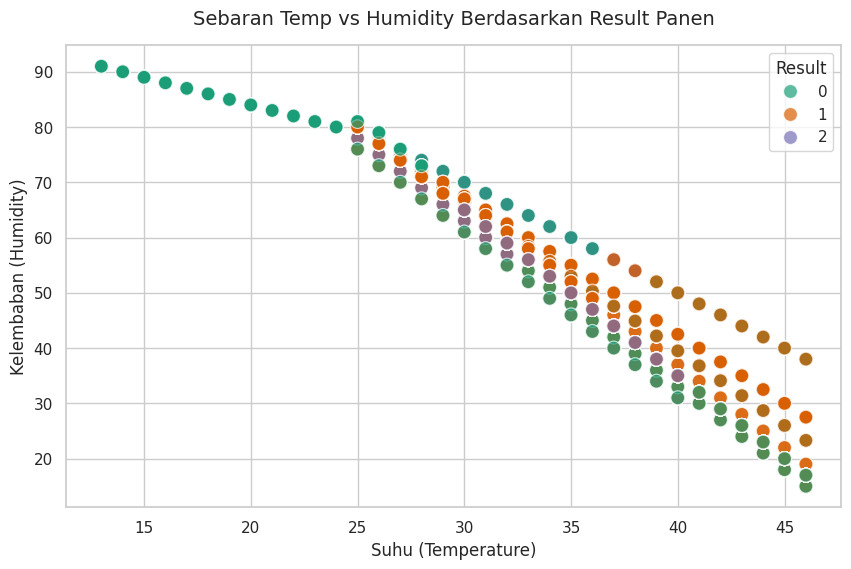

In [161]:
# SCATTER PLOT (Hubungan Suhu & Kelembaban terhadap Hasil)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature', y='humidity', hue='result', palette='Dark2', s=100, alpha=0.7)
plt.title('Sebaran Temp vs Humidity Berdasarkan Result Panen', fontsize=14, pad=15)
plt.xlabel('Suhu (Temperature)', fontsize=12)
plt.ylabel('Kelembaban (Humidity)', fontsize=12)
plt.legend(title='Result')
plt.show()

In [162]:
from google.colab import files

os.makedirs('outputs', exist_ok=True)

path_export = os.path.join('outputs', 'cleaned_data.csv')
df.to_csv(path_export, index=False)

print(f"Data Berhasil disimpan: {path_export}")

# untuk collab cloud
files.download(path_export)

Data Berhasil disimpan: outputs/cleaned_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>